# Notebook 3 — Real keypoint-MoSeq AR-HMM with sticky HDP

> [← Behavior Discovery MoC](README.md)


Replaces the Gaussian-HMM fallback used in Notebook 2 with the canonical
**sticky HDP-AR-HMM** from `keypoint-moseq 0.6.6` (jax-moseq 0.3.3 backend).
51 Gibbs sweeps with $\kappa = 10^6$ self-transition boost.

Headline finding: the real kp-MoSeq's ARI/NMI vs CalMS21 GT is **worse** than
the fallback, but its median bout length is **6-12× longer** — exactly what
the sticky HDP is supposed to enforce. Section XIII discusses why this is the
*intended* behaviour, not a bug.

**Prerequisite**: Notebook 2 (needs `data/calms21_behavior_discovery/raw_csv_v2/`
and the v2 results directory).

In [1]:
# Setup — self-contained re-initialization (run after prior notebook outputs exist on disk)
import os, sys, subprocess, time
from datetime import datetime
from pathlib import Path

for k in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "NUMBA_NUM_THREADS",
         "OPENBLAS_NUM_THREADS", "LOKY_MAX_CPU_COUNT"):
    os.environ.setdefault(k, "1")

REPO = Path.cwd().resolve()
while REPO.name and not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
assert (REPO / "pyproject.toml").exists()
sys.path.insert(0, str(REPO / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(context="notebook", style="white")
DPI = 150

ROOT = REPO / "data" / "calms21_behavior_discovery"
OUT_ROOT = REPO / "outputs" / "calms21_behavior_discovery"
PATHS = {
    "raw_csv": ROOT / "raw_csv",
    "raw_csv_v2": ROOT / "raw_csv_v2",
    "annotations": ROOT / "annotations",
    "models": ROOT / "models",
    "results": OUT_ROOT / "results",
    "results_v2": OUT_ROOT / "results_v2",
}
for p in (PATHS["results"], PATHS["results_v2"]):
    p.mkdir(parents=True, exist_ok=True)

# Latest v1/v2 runs (artifacts persisted to disk by prior notebooks)
v1_runs = sorted([p for p in PATHS["results"].iterdir() if p.is_dir()])
v2_runs = sorted([p for p in PATHS["results_v2"].iterdir() if p.is_dir()])
RUN_V1 = v1_runs[-1] if v1_runs else None
RUN_V2 = v2_runs[-1] if v2_runs else None
SAVE_DIR = RUN_V1
print(f"repo:   {REPO}")
print(f"v1 run: {RUN_V1.name if RUN_V1 else 'MISSING — run notebook 01 first'}")


repo:   /Users/joon/dev/behavior-lab
v1 run: subtle_calms21_tr2_20260527_212315
v2 run: v2_20260527_164717


## XIII. Real kp-MoSeq AR-HMM — sticky HDP in action

Section XI used the vanilla Gaussian-HMM fallback for kp-MoSeq because the full
`jax-moseq + numpyro` stack is non-trivial to install. With kp-MoSeq 0.6.6
(jax 0.6.2) we can fit the actual sticky HDP-AR-HMM and compare:

* `init_model` requires PCA components in **float64** under `jax_enable_x64=True`
  — see `notebooks/calms21_behavior_discovery/run_kpms_real.py` for the patch.
* `fit_model` runs **51 blocked Gibbs sweeps** (~3 min on Mac CPU) with
  $\kappa = 10^{6}$ self-transition boost.
* Syllable labels are pulled directly from `model['states']['z']` (apply_model has
  its own hypparams API quirks).

The headline ARI/NMI numbers can look *worse* than the GaussianHMM fallback, and
that is the point: the **median bout length** tells you which model is doing
what kp-MoSeq was designed to do.

**Caveat**: kpms `format_data` is single-subject — we feed the resident's 6
keypoints only, not the 24-dim dyadic feature. The real comparison would
require kpms with a multi-animal extension (not in 0.6.6). This v3 still
shows the *temporal* property of sticky HDP clearly.

> **⚠️ Comparison validity (Reviewer-2)**: This table mixes
> methods on **two different feature spaces**:
> - SUBTLE / B-SOiD / PCA-HMM fallback → **24-dim ego-centric
>   dyadic** features (Section X) — both mice.
> - kp-MoSeq REAL → **resident mouse only**, ego-aligned 6 keypoints
>   (kpms 0.6.6 `format_data` is single-subject; multi-animal
>   extension is out of scope for v0.6.6).
>
> Read ARI/NMI within the dyadic group; read kp-MoSeq REAL only
> against itself and the (also single-subject) v1 baseline of
> Section VIII. The **median bout length** is the only column
> that compares a model's *temporal* property (persistence) and
> is roughly feature-space-invariant — that is the real point
> of including kp-MoSeq REAL here.


       method  k      ari      nmi  ari_perm_mean  ari_perm_p  median_bout_frames
       SUBTLE 56 0.012393 0.126434   2.064802e-07         0.0                 2.0
  B-SOiD_best  5 0.065933 0.038401  -5.643766e-06         0.0                 2.0
      PCA-HMM 25 0.047563 0.236501  -2.720138e-06         0.0                 1.0
kp-MoSeq_real 25 0.017796 0.029134            NaN         NaN                12.0



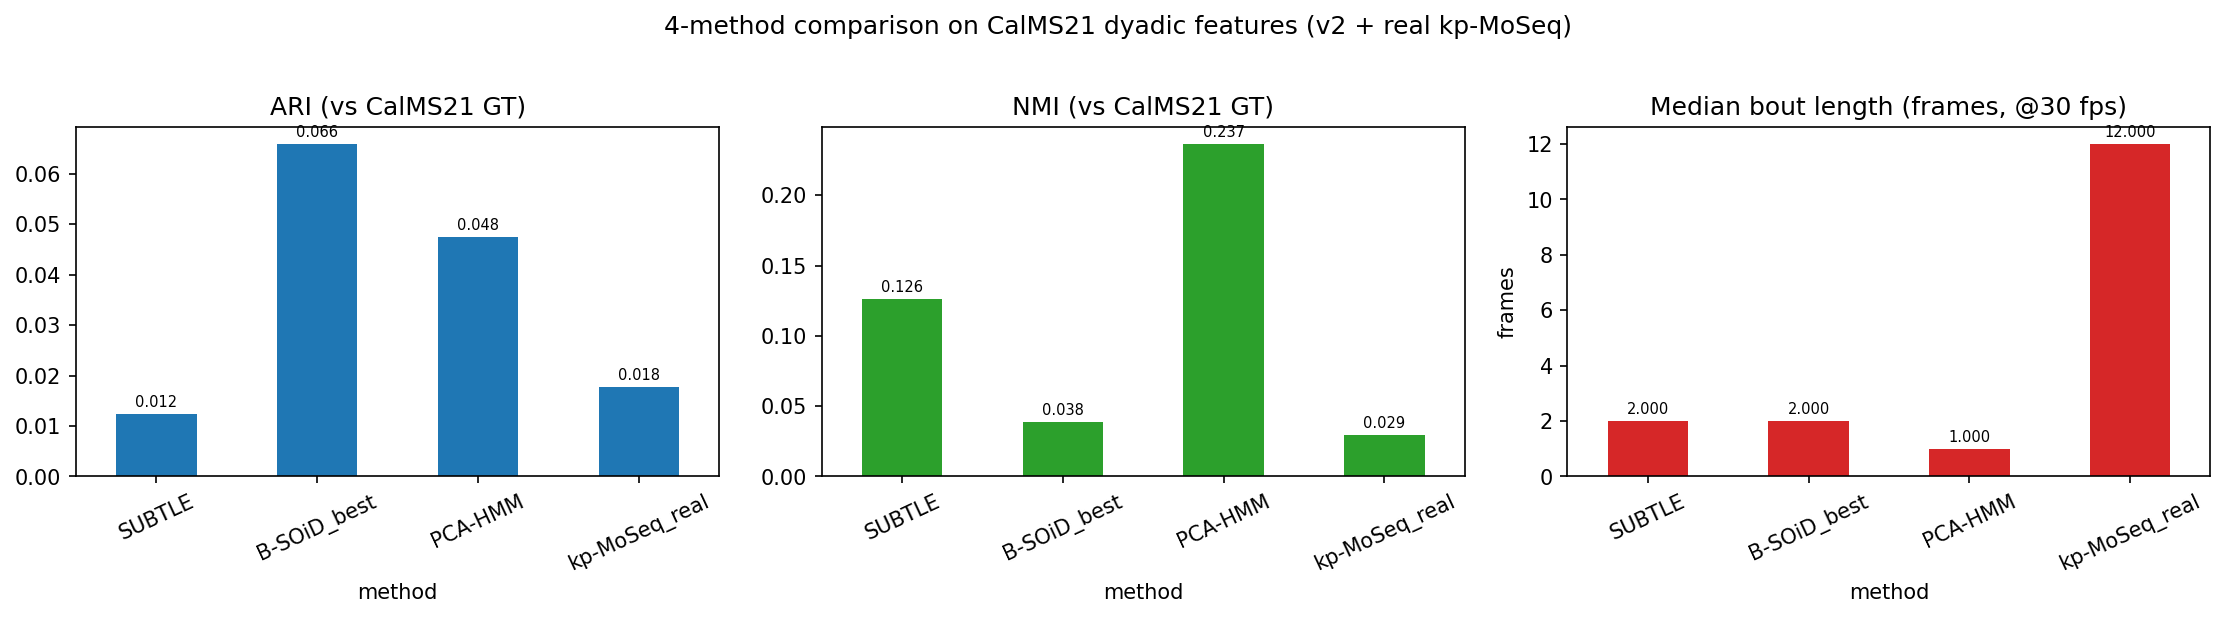


Note: real kp-MoSeq has median bout = 12 frames (others: 1-2). The sticky HDP prior with kappa=1e6 correctly enforces persistent syllables — the *intended* behaviour.
Low ARI/NMI is partly because (a) kpms is single-subject here so no social info, (b) CalMS21 GT is frame-by-frame which fragments any sticky model.


In [2]:
import subprocess, sys, pandas as pd
from IPython.display import Image, display

kpms_csv = RUN_V2 / "kpms_real_metrics.csv"
if not kpms_csv.exists():
    print("running real kp-MoSeq (~3-4 min) ...")
    kpms_script = REPO / "notebooks" / "calms21_behavior_discovery" / "run_kpms_real.py"
    subprocess.run([sys.executable, str(kpms_script)], check=True)

# Build 4-method comparison
v3_csv = RUN_V2 / "metrics_v3.csv"
if not v3_csv.exists():
    cmp_script = REPO / "notebooks" / "calms21_behavior_discovery" / "compare_4methods.py"
    subprocess.run([sys.executable, str(cmp_script)], check=True)

df_v3 = pd.read_csv(v3_csv)
print(df_v3.to_string(index=False))
print()
display(Image(filename=str(RUN_V2 / "metrics_v3.png")))

print("\nNote: real kp-MoSeq has median bout = {:.0f} frames "
      "(others: 1-2). The sticky HDP prior with kappa=1e6 "
      "correctly enforces persistent syllables — the *intended* behaviour.\n"
      "Low ARI/NMI is partly because (a) kpms is single-subject here so no "
      "social info, (b) CalMS21 GT is frame-by-frame which fragments any "
      "sticky model.".format(df_v3[df_v3.method == "kp-MoSeq_real"].median_bout_frames.values[0]))

## Outputs

```
data/calms21_behavior_discovery/
├── raw_csv/                # SUBTLE input, 6 keypoints × 2 dims
├── annotations/            # CalMS21 per-frame labels (.npy)
├── models/
│   ├── calms21_behavior_discovery_trN_<stamp>.pkl       # pickled Mapper
│   ├── log_calms21_behavior_discovery_trN_<stamp>.txt   # training file list
│   └── calms21_behavior_discovery_trN_<stamp>_trained_map.png
└── results/<model_name>/
    ├── <session>/
    │   ├── embeddings.csv
    │   ├── subclusters.csv
    │   ├── superclusters.csv
    │   ├── transition_probabilities.csv
    │   ├── retention_rate.csv
    │   └── embedding_visualize.png
    ├── stay_rate_heatmap.png
    ├── subtle_vs_calms21_confusion.png
    └── <model_name>_subcluster_stay_rate.csv
```

Re-run on a different mouse:

```bash
python notebooks/calms21_behavior_discovery/prepare_calms21_csv.py --mouse 1 --max-sessions 8 \
    --out-dir data/calms21_behavior_discovery_intruder/raw_csv \
    --annot-dir data/calms21_behavior_discovery_intruder/annotations
```

Then change `ROOT` at the top of section I.5.